In [1]:
import ssl
import urllib3
import os
import sys
import json
import time
import re
import pandas as pd
from pathlib import Path

ssl._create_default_https_context = ssl._create_unverified_context
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
os.environ.setdefault('CURL_CA_BUNDLE', '')
os.environ.setdefault('REQUESTS_CA_BUNDLE', '')

HF_CACHE = os.path.abspath('../hf_cache')
os.environ['HF_HOME'] = HF_CACHE
os.environ['HF_HUB_CACHE'] = os.path.join(HF_CACHE, 'hub')

sys.path.insert(0, './pipeline')
import config
import model
from pipeline import routed_pipeline

config.py loaded. HF cache: /d/hpc/projects/onj_fri/no-language-processors-v2/hf_cache


/usr/local/lib/python3.11/dist-packages/transformers/utils/hub.py:106: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


Loading Qwen/Qwen2.5-7B-Instruct from /d/hpc/projects/onj_fri/no-language-processors-v2/hf_cache …


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

WARNING 05-21 10:35:17 config.py:2276] Casting torch.bfloat16 to torch.float16.
INFO 05-21 10:35:33 config.py:510] This model supports multiple tasks: {'embed', 'classify', 'generate', 'reward', 'score'}. Defaulting to 'generate'.
INFO 05-21 10:35:33 llm_engine.py:234] Initializing an LLM engine (v0.6.6.post1) with config: model='Qwen/Qwen2.5-7B-Instruct', speculative_config=None, tokenizer='Qwen/Qwen2.5-7B-Instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.float16, max_seq_len=32768, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto, quantization_param_path=None, device_config=cuda, decoding_config=DecodingConfig(guided_decoding_backend='xgrammar'), observability_config=ObservabilityConfig(otlp_traces_endpoint=None, collect_model_forwa

...

Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]


INFO 05-21 10:40:00 model_runner.py:1099] Loading model weights took 14.2487 GB
INFO 05-21 10:40:09 worker.py:241] Memory profiling takes 9.14 seconds
INFO 05-21 10:40:09 worker.py:241] the current vLLM instance can use total_gpu_memory (31.73GiB) x gpu_memory_utilization (0.90) = 28.56GiB
INFO 05-21 10:40:09 worker.py:241] model weights take 14.25GiB; non_torch_memory takes 0.13GiB; PyTorch activation peak memory takes 4.35GiB; the rest of the memory reserved for KV Cache is 9.82GiB.
INFO 05-21 10:40:10 gpu_executor.py:76] # GPU blocks: 11497, # CPU blocks: 4681
INFO 05-21 10:40:10 gpu_executor.py:80] Maximum concurrency for 32768 tokens per request: 5.61x
INFO 05-21 10:40:16 model_runner.py:1415] Capturing cudagraphs for decoding. This may lead to unexpected consequences if the model is not static. To run the model in eager mode, set 'enforce_eager=True' or use '--enforce-eager' in the CLI. If out-of-memory error occurs during cudagraph capture, consider decreasing `gpu_memory_utiliz

Capturing CUDA graph shapes: 100%|██████████| 35/35 [00:36<00:00,  1.04s/it]

INFO 05-21 10:40:52 model_runner.py:1535] Graph capturing finished in 36 secs, took 0.20 GiB
INFO 05-21 10:40:52 llm_engine.py:431] init engine (profile, create kv cache, warmup model) took 51.50 seconds


Model loaded.
router.py loaded.
parser.py loaded.
validator.py loaded.
cost_judge.py loaded.
tap.py loaded.
simple_pipeline.py loaded.
complex_pipeline.py loaded.
pipeline.py loaded. Use routed_pipeline(query) to run.


In [4]:
import ssl
import urllib3
import os
import sys
import json
import time
import re
import pandas as pd
from pathlib import Path


In [2]:
INPUT_CSV           = 'gaia_eval_dataset_v2.csv'
OUTPUT_CSV          = 'eval_resultss.csv'
SKIP_GAIA_EXECUTION = True
SAVE_EVERY          = 5

In [7]:
import threading

TIMEOUT_SECONDS = 10

def extract_adql(output_json):
    steps = output_json.get('execution', [])
    return ' ; '.join(s['adql'] for s in steps if s.get('adql'))

# (3) clean start — delete any previous results
if os.path.exists(OUTPUT_CSV):
    os.remove(OUTPUT_CSV)
    print(f'Removed existing {OUTPUT_CSV}')

def run_with_timeout(question, timeout):
    """Run routed_pipeline in a thread; return None if it takes longer than `timeout`."""
    result = {'value': None, 'error': None}
    def target():
        try:
            result['value'] = routed_pipeline(question, skip_gaia_execution=SKIP_GAIA_EXECUTION)
        except Exception as e:
            result['error'] = str(e)
    thread = threading.Thread(target=target, daemon=True)
    thread.start()
    thread.join(timeout)
    if thread.is_alive():
        return None, 'timeout'
    return result['value'], result['error']

df_eval = pd.read_csv(INPUT_CSV)
header_written = False

for i, row in df_eval.iterrows():
    record = {
        'question':         row['question'],
        'intent':           row.get('intent'),
        'complexity':       row.get('complexity'),
        'sql':              row['sql'],
        'generated_sql':    None,
        'duration_seconds': None,
        'status':           None,
        'error':            None,
    }
    t0 = time.time()
    result, err = run_with_timeout(row['question'], TIMEOUT_SECONDS)
    record['duration_seconds'] = round(time.time() - t0, 2)

    if err == 'timeout':
        record['status'] = 'timeout'
        record['error']  = f'exceeded {TIMEOUT_SECONDS}s'
        print(f'[{i+1}/{len(df_eval)}] ⏱  timeout')
    elif err:
        record['status'] = 'failed'
        record['error']  = err
        print(f'[{i+1}/{len(df_eval)}] ✗ failed: {err}')
    elif result is None:
        record['status'] = 'no_query'
    else:
        record['generated_sql'] = extract_adql(result['output_json'])
        record['status']        = 'success' if record['generated_sql'] else 'no_query'
        print(f'[{i+1}/{len(df_eval)}] ✓ {record["duration_seconds"]}s')

    pd.DataFrame([record]).to_csv(
        OUTPUT_CSV,
        mode='a',
        header=not header_written,
        index=False,
    )
    header_written = True

print(f'\nDone. Results in {OUTPUT_CSV}')


════════════════════════════════════════════════════════════
  USER QUERY: Find 500 bright stars around the Pleiades cluster.
════════════════════════════════════════════════════════════

[Router] Classifying query …


Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  1.88it/s, est. speed input: 719.35 toks/s, output: 37.66 toks/s]


  🟢  Verdict: SIMPLE
      Reason: single cone search with a magnitude filter


  USER QUERY: Find 500 bright stars around the Pleiades cluster.

[Attempt 1/3] Parsing …


Processed prompts: 100%|██████████| 1/1 [00:01<00:00,  1.67s/it, est. speed input: 842.43 toks/s, output: 38.29 toks/s]


  Parsed JSON:
{
  "intent": "cone_search",
  "ra": 56.75,
  "dec": 24.12,
  "radius": 1.0,
  "columns": [
    "source_id",
    "phot_g_mean_mag"
  ],
  "filters": {
    "phot_g_mean_mag": {
      "max": 4.0
    }
  },
  "join_table": null,
  "limit": 500
}
  JSON valid.
  ADQL: SELECT TOP 500 source_id, phot_g_mean_mag, ra, dec, bp_rp, pmra, pmdec FROM gaiadr3.gaia_source WHERE 1=CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', 56.75, 24.12, 1.0)) AND phot_g_mean_mag <= 4.0 ORDER BY random_index
  ADQL syntax valid.
  Evaluating cost …


...

  🟢  Verdict: SIMPLE
      Reason: single HR diagram with a spatial filter


  USER QUERY: Generate an HR diagram for 500 random stars near the Galactic Centre.

[Attempt 1/3] Parsing …


Processed prompts: 100%|██████████| 1/1 [00:01<00:00,  1.61s/it, est. speed input: 877.46 toks/s, output: 37.34 toks/s]


  Parsed JSON:
{
  "intent": "hr_diagram",
  "ra": 266.4,
  "dec": -29.0,
  "radius": 1.0,
  "columns": [
    "source_id",
    "parallax",
    "phot_g_mean_mag",
    "bp_rp"
  ],
  "filters": {},
  "join_table": null,
  "limit": 500
}
  JSON valid.
  ADQL: SELECT TOP 500 source_id, parallax, phot_g_mean_mag, bp_rp, ra, dec, pmra, pmdec, (phot_g_mean_mag + 5*LOG10(parallax/100)) AS abs_g_mag FROM gaiadr3.gaia_source WHERE 1=CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', 266.4, -29.0, 1.0)) AND parallax > 0 AND bp_rp IS NOT NULL ORDER BY random_index
  ADQL syntax valid.
  Evaluating cost …


Processed prompts: 100%|██████████| 1/1 [00:02<00:00,  2.68s/it, est. speed input: 225.81 toks/s, output: 44.41 toks/s]

  ────────────────────────────────────────────────────
  🟠  COST: EXPENSIVE  (score 75/100)
  ────────────────────────────────────────────────────
    ⚠️  TOP > 50000
    ⚠️  Cone radius > 2°
    ⚠️  ORDER BY on non-indexed column (random_index)
    💡 Reduce TOP to 50
    💡 Shrink cone radius to ≤ 0.5°
    💡 Replace ORDER BY random_index with a parallax threshold filter
  ────────────────────────────────────────────────────
  parallax > 0  →  parallax > 1
  LLM judge also suggested:
    • Reduce TOP to 50
    • Shrink cone radius to ≤ 0.5°
    • Replace ORDER BY random_index with a parallax threshold filter
  Optimised ADQL: SELECT TOP 500 source_id, parallax, phot_g_mean_mag, bp_rp, ra, dec, pmra, pmdec, (phot_g_mean_mag + 5*LOG10(parallax/100)) AS abs_g_mag FROM gaiadr3.gaia_source WHERE 1=CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', 266.4, -29.0, 1.0)) AND parallax > 1 AND bp_rp IS NOT NULL ORDER BY random_index
  ⊘  Gaia execution skipped (flag: skip_gaia_execution=True)

  ✓  0

Total rows : 40
Valid      : 11 / 40  (27.5%)
Mean score : 0.738
Status     : {'success': 37, 'failed': 2, 'timeout': 1}

By intent:
                    valid  score  intent_match  col_superset  \
intent                                                         
cone_search           0.3  0.672           0.7           0.9   
hr_diagram            0.4  0.910           1.0           1.0   
nearest_neighbours    0.3  0.786           0.7           0.9   
stellar_population    0.1  0.583           0.5           0.8   

                    constraint_superset  
intent                                   
cone_search                         0.5  
hr_diagram                          1.0  
nearest_neighbours                  0.5  
stellar_population                  0.6  

By complexity:
            valid  score
complexity              
Simple      0.275  0.738

Counts per intent:
outcome             pass  fail  no_render
intent                                   
hr_diagram             4     6     

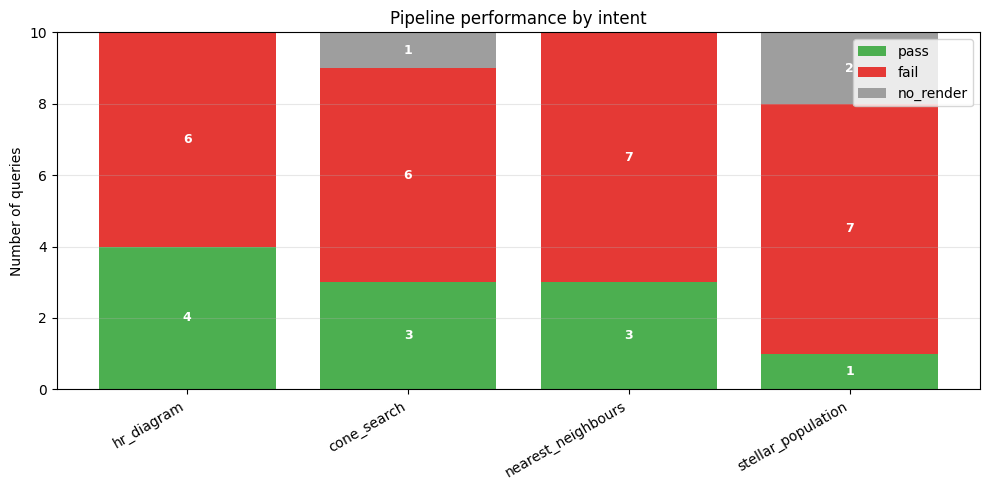

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def extract_adql(output_json):
    steps = output_json.get('execution', [])
    return ' ; '.join(s['adql'] for s in steps if s.get('adql'))

def extract_cols(q):
    if not isinstance(q, str): return set()
    m = re.search(r'select(.*?)from', q.lower(), re.DOTALL)
    if not m: return set()
    raw = re.sub(r'^\s*top\s+\d+\s*', '', m.group(1).strip())
    if raw.strip() == '*': return {'*'}
    cols = set()
    for part in raw.split(','):
        part = re.sub(r'^[\w]+\.', '', part.strip())
        part = re.sub(r'\s+as\s+\w+', '', part)
        part = re.split(r'[\s\+\-\*\/\(\)]', part)[0]
        if part: cols.add(part)
    return cols

def extract_where(q):
    if not isinstance(q, str): return set()
    m = re.search(r'where(.*?)(?:group by|order by|limit|having|$)', q.lower(), re.DOTALL)
    if not m: return set()
    skip = {'and','or','not','is','null','between','in','like','as','true','false','',
            'contains','point','circle','icrs'}
    tokens = re.split(r"[\s,\(\)\!\=<>\+\-\*\/']+", m.group(1))
    return {re.sub(r'^[\w]+\.','',t) for t in tokens
            if t not in skip and not re.match(r'^[\d\.\-]+$', t) and len(t) > 1}

def extract_intent(q):
    if not isinstance(q, str): return None
    qu = q.upper()
    if 'JOIN' in qu: return 'internal_crossmatch'
    if 'ORDER BY PARALLAX DESC' in qu: return 'nearest_neighbours'
    if "PHOT_VARIABLE_FLAG = 'VARIABLE'" in qu: return 'variability_search'
    if 'ABS_G_MAG' in qu or 'LOG10(PARALLAX' in qu: return 'hr_diagram'
    if 'RADIAL_VELOCITY IS NOT NULL' in qu: return 'velocity_computation'
    if 'CONTAINS' in qu and 'BP_RP' in qu and 'IS NOT NULL' in qu: return 'color_histogram'
    if 'CONTAINS' in qu: return 'cone_search'
    return 'stellar_population'


def extract_numeric_constraints(q):
    """
    Extract (column, operator, value) triples and CIRCLE coordinates from WHERE.
    Returns a dict like:
      {
        'parallax':         [('>', 5.0)],
        'phot_g_mean_mag':  [('<', 15.0)],
        'teff_gspphot':     [('between', 2400.0, 3900.0)],
        '_circle':          [(266.4, -29.0, 1.0)],   # ra, dec, radius
      }
    """
    if not isinstance(q, str): return {}
    q = q.lower()
    m = re.search(r'where(.*?)(?:group by|order by|limit|having|$)', q, re.DOTALL)
    if not m: return {}
    where = m.group(1)
    out = {}

    # CIRCLE('ICRS', ra, dec, radius)
    for ra, dec, rad in re.findall(
        r"circle\s*\(\s*'icrs'\s*,\s*([\-\d\.]+)\s*,\s*([\-\d\.]+)\s*,\s*([\d\.]+)\s*\)", where):
        out.setdefault('_circle', []).append((float(ra), float(dec), float(rad)))

    # col BETWEEN a AND b
    for col, a, b in re.findall(r'(\w+)\s+between\s+([\-\d\.]+)\s+and\s+([\-\d\.]+)', where):
        col = re.sub(r'^[\w]+\.', '', col)
        out.setdefault(col, []).append(('between', float(a), float(b)))

    # col <op> number
    for col, op, val in re.findall(r'(\w+)\s*(>=|<=|>|<|=)\s*([\-\d\.]+)', where):
        col = re.sub(r'^[\w]+\.', '', col)
        out.setdefault(col, []).append((op, float(val)))

    return out


def constraint_is_at_least_as_restrictive(ref_op, ref_val, pred_op, pred_val):
    """
    Is `pred` at least as restrictive as `ref` for the same column?
    Examples:
      ref:  parallax > 5    pred:  parallax > 10   → TRUE  (10 > 5, narrower set)
      ref:  parallax > 5    pred:  parallax > 1    → FALSE (1 < 5, broader set)
      ref:  teff < 4000     pred:  teff < 3500     → TRUE  (3500 < 4000, narrower)
    """
    if ref_op in ('>', '>=') and pred_op in ('>', '>='):
        return pred_val >= ref_val
    if ref_op in ('<', '<=') and pred_op in ('<', '<='):
        return pred_val <= ref_val
    if ref_op == '=' and pred_op == '=':
        return ref_val == pred_val
    return False  # operator mismatch — can't compare


def numeric_constraint_score(ref_nums, pred_nums):
    """
    Returns (coverage, all_restrictive, details).
    - coverage: fraction of ref constraints that pred satisfies at least as tightly
    - all_restrictive: True iff every ref constraint is satisfied
    """
    if not ref_nums:
        return 1.0, True, []

    satisfied, total, details = 0, 0, []
    for col, ref_constraints in ref_nums.items():
        if col == '_circle':
            continue  # handled separately
        for ref_c in ref_constraints:
            total += 1
            pred_cs = pred_nums.get(col, [])
            ok = False
            if ref_c[0] == 'between':
                _, a, b = ref_c
                # pred is tighter if its range is inside [a,b]
                for pc in pred_cs:
                    if pc[0] == 'between' and pc[1] >= a and pc[2] <= b:
                        ok = True; break
                    if pc[0] in ('>','>=') and pc[1] >= a:
                        ok = True; break
                    if pc[0] in ('<','<=') and pc[1] <= b:
                        ok = True; break
            else:
                op, val = ref_c
                ok = any(constraint_is_at_least_as_restrictive(op, val, p[0], p[1])
                         for p in pred_cs if p[0] != 'between')
            if ok:
                satisfied += 1
            else:
                details.append(f'{col} {ref_c} not satisfied (pred: {pred_cs})')

    coverage = satisfied / total if total else 1.0
    return coverage, coverage == 1.0, details


def spatial_overlap(ref_circles, pred_circles, tol_deg=0.5):
    """
    Are the queries asking about the same sky region?
    Two circles 'match' if their centres are within tol_deg of each other
    AND the predicted radius is <= the reference radius (tighter cone).
    """
    if not ref_circles:
        return True, []
    if not pred_circles:
        return False, ['no cone in prediction']

    details = []
    for ra_r, dec_r, rad_r in ref_circles:
        matched = False
        for ra_p, dec_p, rad_p in pred_circles:
            d = ((ra_p - ra_r) ** 2 + (dec_p - dec_r) ** 2) ** 0.5
            if d <= tol_deg and rad_p <= rad_r + 0.1:
                matched = True
                break
        if not matched:
            details.append(f'no cone within {tol_deg}° of ({ra_r}, {dec_r}, r={rad_r})')
    return len(details) == 0, details

def score(ref, pred):
    if not isinstance(pred, str) or not pred.strip():
        return {'valid': False, 'score': 0.0, 'col_superset': False,
                'constraint_superset': False, 'intent_match': False,
                'numeric_ok': False, 'spatial_ok': False,
                'missing_constraints': [], 'numeric_details': [], 'spatial_details': [],
                'ref_intent': None, 'pred_intent': None}

    rc, pc = extract_cols(ref), extract_cols(pred)
    rw, pw = extract_where(ref), extract_where(pred)
    rn, pn = extract_numeric_constraints(ref), extract_numeric_constraints(pred)
    ri, pi = extract_intent(ref), extract_intent(pred)

    col_ok  = '*' in pc or '*' in rc or rc.issubset(pc)
    col_cov = 1.0 if ('*' in pc or '*' in rc) else (len(rc & pc) / len(rc) if rc else 1.0)

    cstr_ok  = rw.issubset(pw)
    cstr_cov = len(rw & pw) / len(rw) if rw else 1.0

    num_cov, num_ok, num_details = numeric_constraint_score(rn, pn)
    sp_ok, sp_details = spatial_overlap(rn.get('_circle', []), pn.get('_circle', []))
    intent_ok = (ri == pi)

    return {
        'valid': col_ok and cstr_ok and intent_ok and num_ok and sp_ok,
        'score': round(0.20 * col_cov + 0.25 * cstr_cov + 0.20 * intent_ok +
                       0.20 * num_cov + 0.15 * float(sp_ok), 4),
        'col_superset': col_ok,
        'constraint_superset': cstr_ok,
        'intent_match': intent_ok,
        'numeric_ok': num_ok,
        'spatial_ok': sp_ok,
        'missing_constraints': sorted(rw - pw),
        'numeric_details': num_details,
        'spatial_details': sp_details,
        'ref_intent': ri,
        'pred_intent': pi,
    }

results = pd.read_csv(OUTPUT_CSV)
scores  = results.apply(lambda r: score(r['sql'], r['generated_sql']), axis=1)
results = pd.concat([results, pd.DataFrame(scores.tolist())], axis=1)

print(f'Total rows : {len(results)}')
print(f'Valid      : {results["valid"].sum()} / {len(results)}  ({100*results["valid"].mean():.1f}%)')
print(f'Mean score : {results["score"].mean():.3f}')
print(f'Status     : {dict(results["status"].value_counts())}')

print('\nBy intent:')
print(results.groupby('intent')[['valid','score','intent_match','col_superset','constraint_superset']].mean().round(3))

print('\nBy complexity:')
print(results.groupby('complexity')[['valid','score']].mean().round(3))

# ── classify each row ─────────────────────────────────────────────────────────
def classify(row):
    if row['status'] in ('failed', 'timeout', 'no_query'):
        return 'no_render'
    return 'pass' if row['valid'] else 'fail'

results['outcome'] = results.apply(classify, axis=1)

# ── counts per intent × outcome ───────────────────────────────────────────────
counts = (
    results.groupby(['intent', 'outcome']).size()
    .unstack(fill_value=0)
    .reindex(columns=['pass', 'fail', 'no_render'], fill_value=0)
    .sort_values('pass', ascending=False)
)

print('\nCounts per intent:')
print(counts)

# ── stacked bar chart ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(counts))
colors = {'pass': '#4CAF50', 'fail': '#E53935', 'no_render': '#9E9E9E'}

bottom = np.zeros(len(counts))
for outcome in ['pass', 'fail', 'no_render']:
    vals = counts[outcome].values
    ax.bar(x, vals, bottom=bottom, label=outcome, color=colors[outcome])
    # number labels on each segment
    for i, v in enumerate(vals):
        if v > 0:
            ax.text(i, bottom[i] + v / 2, str(v), ha='center', va='center',
                    color='white', fontweight='bold', fontsize=9)
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(counts.index, rotation=30, ha='right')
ax.set_ylabel('Number of queries')
ax.set_title('Pipeline performance by intent')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Counts per intent:
outcome             pass  near_miss  fail  no_render
HR Diagram             4          4     2          0
Cone Search            3          2     4          1
Nearest Stars          3          2     5          0
Stellar Population     1          3     4          2


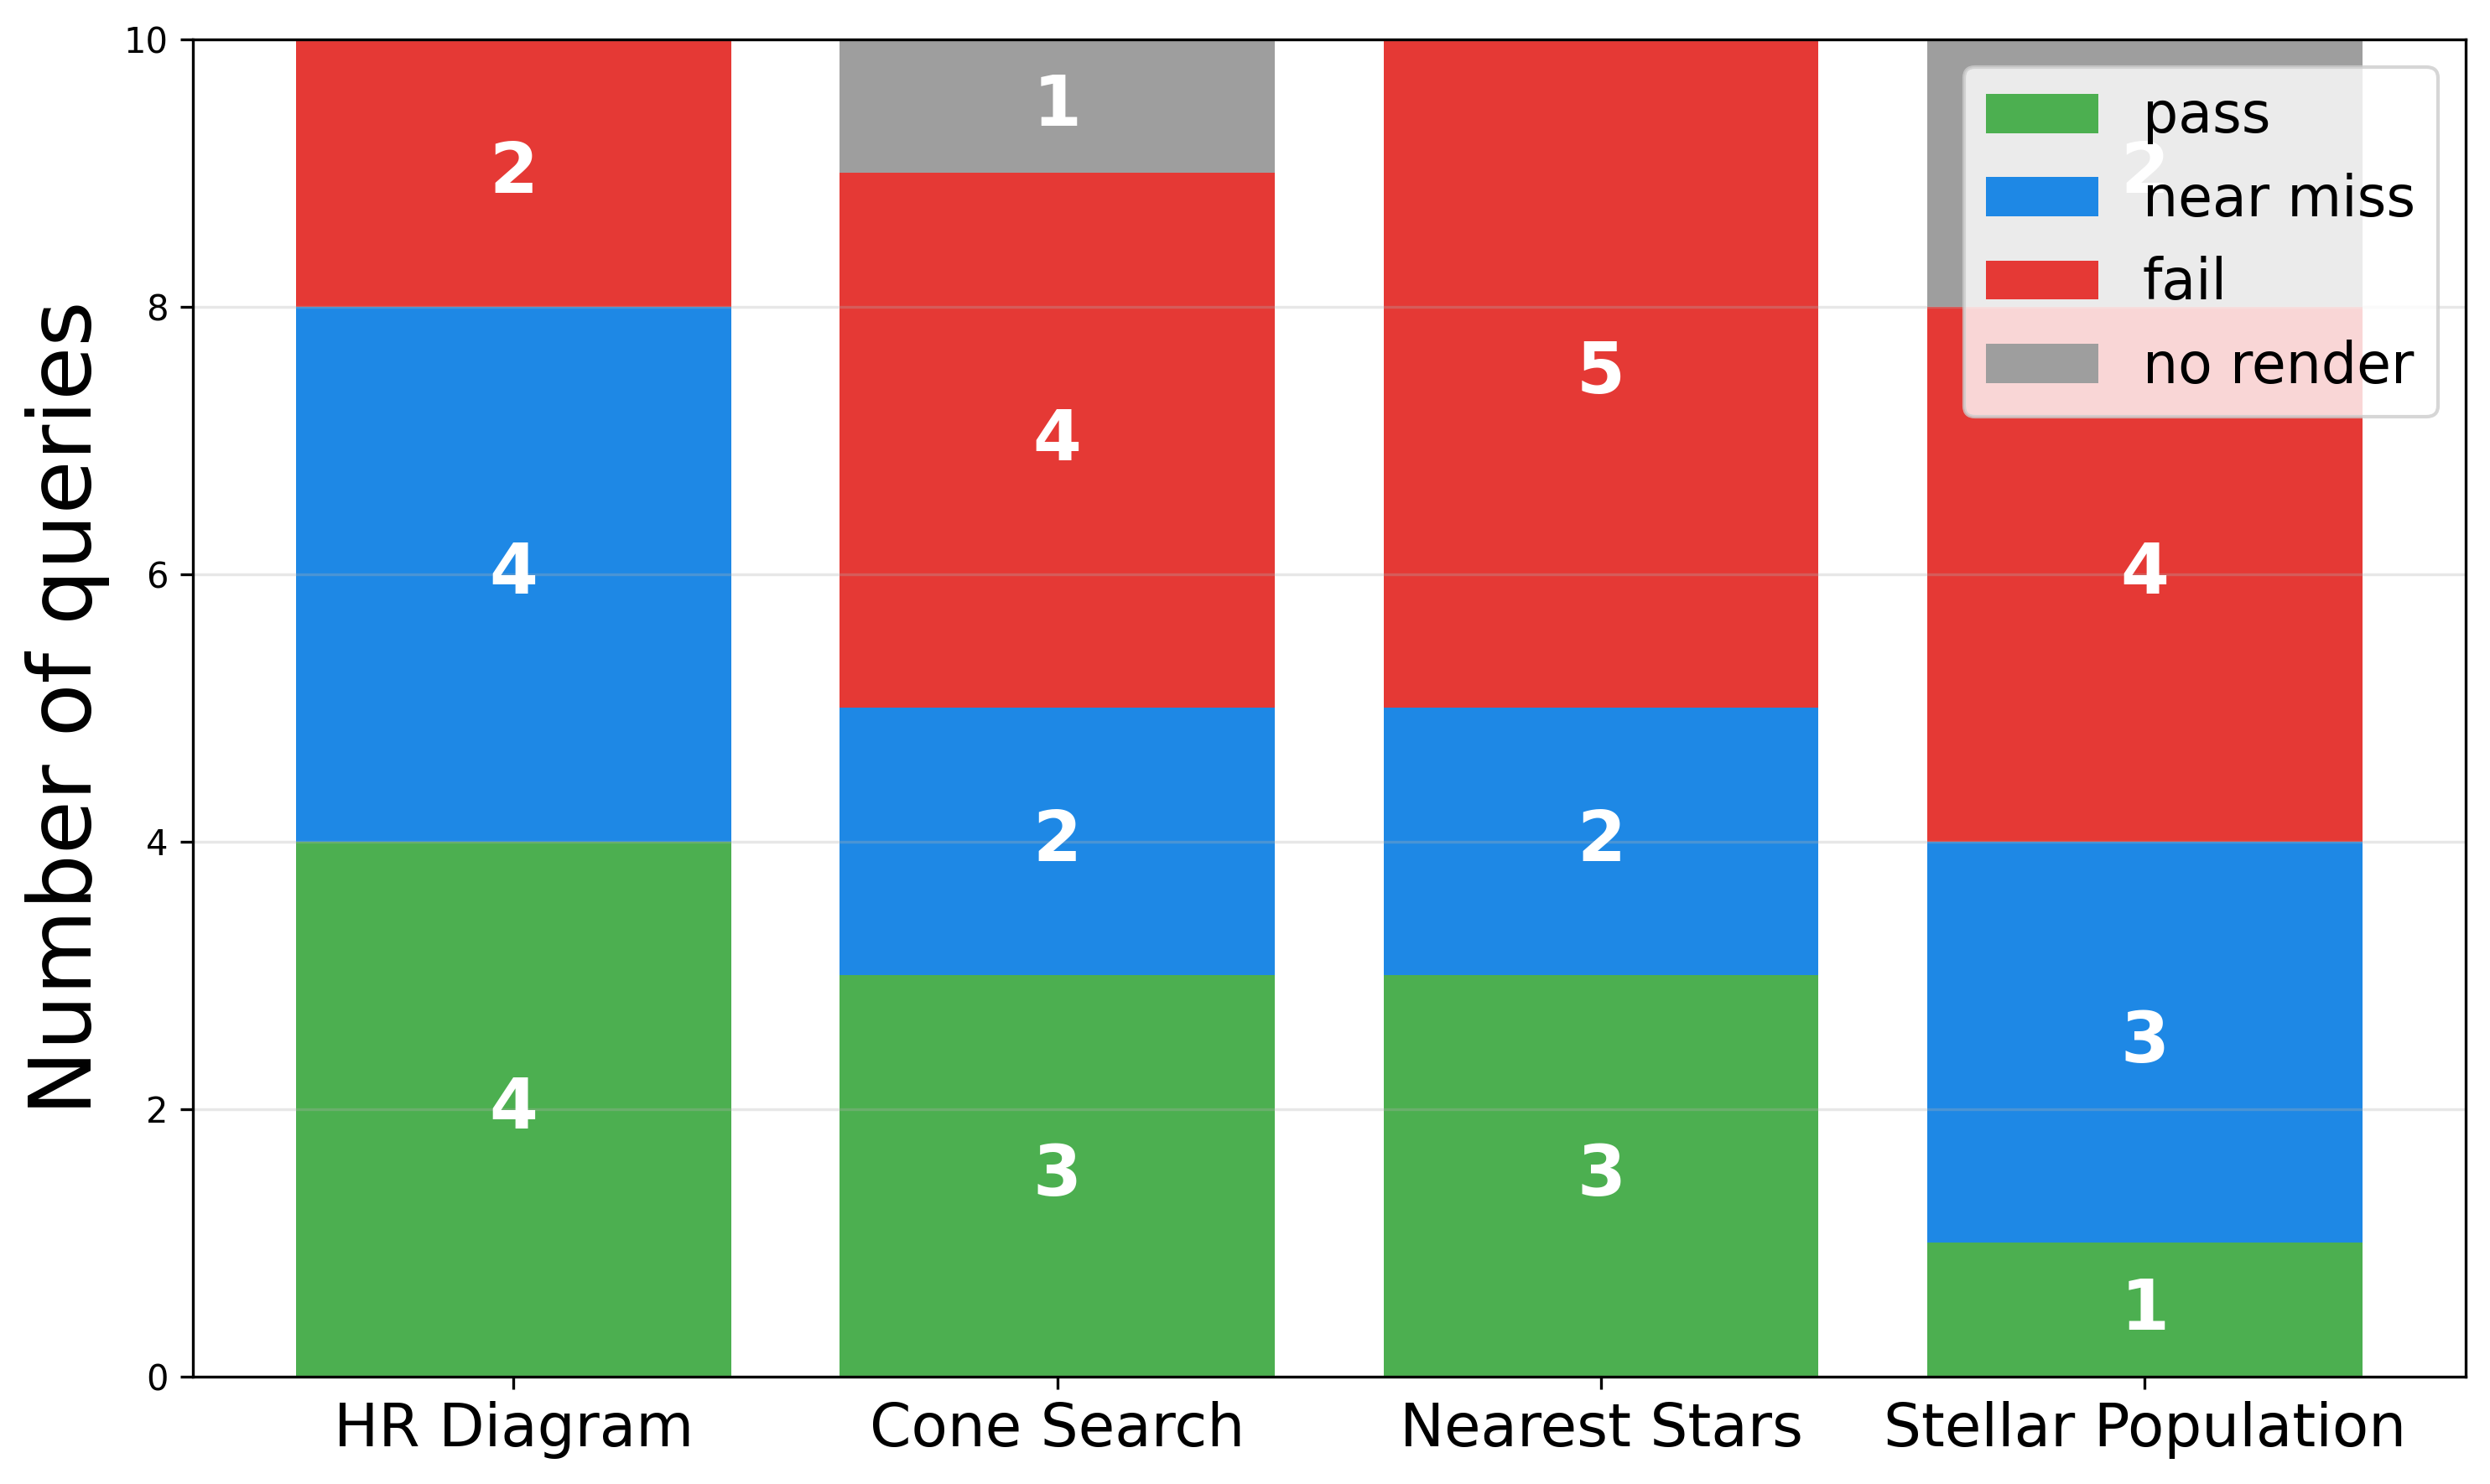

In [15]:
CHECKS = ['col_superset', 'constraint_superset', 'intent_match', 'numeric_ok', 'spatial_ok']
def classify(row):
    if row['status'] in ('failed', 'timeout', 'no_query'):
        return 'no_render'
    n_fail = sum(not row[c] for c in CHECKS)
    if n_fail == 0:
        return 'pass'
    if n_fail == 1:
        return 'near_miss'
    return 'fail'
results['outcome'] = results.apply(classify, axis=1)
ORDER = ['pass', 'near_miss', 'fail', 'no_render']
counts = (
    results.groupby(['intent', 'outcome']).size()
    .unstack(fill_value=0)
    .reindex(columns=ORDER, fill_value=0)
    .sort_values('pass', ascending=False)
)

INTENT_LABELS = {
    'hr_diagram':         'HR Diagram',
    'cone_search':        'Cone Search',
    'nearest_neighbours': 'Nearest Stars',
    'stellar_population': 'Stellar Population',
}
counts.index = [INTENT_LABELS.get(i, i) for i in counts.index]

print('\nCounts per intent:')
print(counts)
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
x = np.arange(len(counts))
colors = {
    'pass':      '#4CAF50',
    'near_miss': '#1E88E5',
    'fail':      '#E53935',
    'no_render': '#9E9E9E',
}
bottom = np.zeros(len(counts))
for outcome in ORDER:
    vals = counts[outcome].values
    ax.bar(x, vals, bottom=bottom, label=outcome.replace('_', ' '), color=colors[outcome])
    for i, v in enumerate(vals):
        if v > 0:
            ax.text(i, bottom[i] + v / 2, str(v), ha='center', va='center',
                    color='white', fontweight='bold', fontsize=20)
    bottom += vals
ax.set_xticks(x)
ax.set_xticklabels(counts.index, rotation=0, ha='center', fontsize=17)
ax.set_ylabel('Number of queries', fontsize=25)
ax.legend(loc='upper right', fontsize=16, title_fontsize=20)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('evaluation.png', dpi=300, bbox_inches='tight')
plt.show()